# ARCSS, AW/chl and SibCIOM profile comparison

- `ARCSS Chl-a`,
- `AW/chl` из `compute_aw_fields(...)`,
- `SibCIOM phyto` из месячного `mthYYYY-MM.nc`.


- так как совпадающих лет с ARCSS обычно нет, берётся ближайший доступный год.


In [1]:
from pathlib import Path
from datetime import datetime
import re

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython import get_ipython

from data_paths import AW_DIR, BIOEXP, grid_dir
from getgrid import getgrid
from vert_profile import compute_aw_fields, prepare_aw_3dvar
from phyto_sibciom import prepare_sibciom_3dvar

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "widget")

URL = (
    "https://www.nodc.noaa.gov/archive/arc0028/0063065/1.1/"
    "data/0-data/ARCSS-PP.csv"
)
LOCAL_CSV = Path("ARCSS-PP.csv")

LIGHT_SCHEME = "jerlov_two_component"
LIGHT_SCHEME = "beer_chl"
JERLOV_TYPE = 1
JERLOV_P = None
JERLOV_LAMBDA1 = None
JERLOV_LAMBDA2 = None
JERLOV_LAMBDA_UNITS = "cm^-1"

YEAR_MIN = 1990
YEAR_MAX = 2015
MONTHS = [6,7]
Z_PLOT_MAX = 150
LAT_MIN_DATA = 50
LAT_MIN_MAP = 40
LAT_MAX = 90
PROJECTION_SCALE = 0.9

clicked_profiles = []  # can also be filled manually, e.g. [13834, 13782]


ModuleNotFoundError: No module named 'pandas'

In [ ]:
if not LOCAL_CSV.exists():
    df = pd.read_csv(URL, na_values=[-999999, -999999.0])
    df.to_csv(LOCAL_CSV, index=False)
else:
    df = pd.read_csv(LOCAL_CSV, na_values=[-999999, -999999.0])

required = [
    "IDxyt",
    "Year",
    "Month",
    "Day",
    "Lat",
    "Lon",
    "StationDepth(m)",
    "SampleDepth(m)",
    "Chla(mg/m^3)",
    "Source",
]
missing = sorted(set(required) - set(df.columns))
if missing:
    raise ValueError(f"Missing columns in ARCSS-PP.csv: {missing}")

chl = df[required].copy()
chl = chl.dropna(subset=["IDxyt", "Lat", "Lon", "SampleDepth(m)", "Chla(mg/m^3)"])
chl = chl[chl["Chla(mg/m^3)"] >= 0]
chl = chl[chl["SampleDepth(m)"] >= 0]
chl["date"] = pd.to_datetime(
    {
        "year": chl["Year"].astype("Int64"),
        "month": chl["Month"].astype("Int64"),
        "day": chl["Day"].astype("Int64"),
    },
    errors="coerce",
)

profile_meta = (
    chl.groupby("IDxyt")
    .agg(
        n_depths=("SampleDepth(m)", "nunique"),
        z_min=("SampleDepth(m)", "min"),
        z_max=("SampleDepth(m)", "max"),
        lat=("Lat", "first"),
        lon=("Lon", "first"),
        station_depth_m=("StationDepth(m)", "first"),
        date=("date", "first"),
        source=("Source", "first"),
    )
)

deep_enough = (
    (
        (profile_meta["station_depth_m"] <= 50)
        & (profile_meta["z_max"] >= (profile_meta["station_depth_m"] - 15))
    )
    |
    (
        (profile_meta["station_depth_m"] > 50)
        & (profile_meta["z_max"] >= 75)
    )
    |
    (
        profile_meta["station_depth_m"].isna()
        & (profile_meta["z_max"] >= 75)
    )
)

valid_profiles = profile_meta[
    (profile_meta["n_depths"] >= 4)
    & (profile_meta["z_min"] <= 10)
    & deep_enough
].copy()
valid_profiles["date"] = pd.to_datetime(valid_profiles["date"], errors="coerce")
valid_profiles["year"] = valid_profiles["date"].dt.year
valid_profiles["month"] = valid_profiles["date"].dt.month

profiles_for_map = valid_profiles.dropna(subset=["date"]).copy()
mask = profiles_for_map["year"].between(YEAR_MIN, YEAR_MAX)
if MONTHS is not None:
    mask &= profiles_for_map["month"].isin(MONTHS)
profiles_for_map = profiles_for_map[mask].copy()

print(f"ARCSS rows with Chl-a: {len(chl)}")
print(f"Valid ARCSS profiles after QC: {len(valid_profiles)}")
print(f"Profiles available on map: {len(profiles_for_map)}")
print(f"ARCSS date span: {valid_profiles['date'].min().date()} .. {valid_profiles['date'].max().date()}")


ARCSS rows with Chl-a: 80816
Valid ARCSS profiles after QC: 5773
Profiles available on map: 987
ARCSS date span: 1954-04-17 .. 2004-08-24


In [ ]:
mask_grid, grid_lon, grid_lat, grid_z, _, _, _ = getgrid(base_dir=Path(grid_dir))
wet_mask = np.asarray(mask_grid) != 0
grid_lon = np.asarray(grid_lon, dtype=float)
grid_lat = np.asarray(grid_lat, dtype=float)
grid_z = np.asarray(grid_z, dtype=float)

aw_month_re = re.compile(r"chl(\d{4})-(\d{2})$")
aw_daily_re = re.compile(r"day(\d{4})-(\d{2})-(\d{2})\.nc$")
sib_month_re = re.compile(r"mth(\d{4})-(\d{2})\.nc$")

aw_available_months = set()
for year_dir in Path(AW_DIR, "Chl_DATA").glob("[0-9][0-9][0-9][0-9]"):
    if not year_dir.is_dir():
        continue
    for p in year_dir.iterdir():
        m = aw_month_re.match(p.name)
        if m:
            aw_available_months.add((int(m.group(1)), int(m.group(2))))

aw_wind_dates = set()
for p in Path(AW_DIR, "wind_data").glob("day????-??-??.nc"):
    m = aw_daily_re.match(p.name)
    if m:
        aw_wind_dates.add(pd.Timestamp(year=int(m.group(1)), month=int(m.group(2)), day=int(m.group(3))))

aw_temp_dates = set()
for p in Path(AW_DIR, "DAY_temp_1", "ocn").glob("day????-??-??.nc"):
    m = aw_daily_re.match(p.name)
    if m:
        aw_temp_dates.add(pd.Timestamp(year=int(m.group(1)), month=int(m.group(2)), day=int(m.group(3))))

aw_daily_dates = sorted(
    dt for dt in (aw_wind_dates & aw_temp_dates)
    if (dt.year, dt.month) in aw_available_months
)

sib_available_months = set()
for p in Path(BIOEXP).glob("mth????-??.nc"):
    m = sib_month_re.match(p.name)
    if m:
        sib_available_months.add((int(m.group(1)), int(m.group(2))))

aw_years = sorted({dt.year for dt in aw_daily_dates})
sib_years = sorted({year for year, month in sib_available_months})

aw_cache = {}
sib_cache = {}


def nearest_wet_point(lon, lat):
    dlon = ((grid_lon - float(lon) + 180.0) % 360.0) - 180.0
    dlat = grid_lat - float(lat)
    dist2 = dlon * dlon + dlat * dlat
    dist2 = np.where(wet_mask, dist2, np.nan)
    flat_idx = int(np.nanargmin(dist2))
    i, j = np.unravel_index(flat_idx, dist2.shape)
    return int(i), int(j)


def nearest_year(target_year, years, label):
    if not years:
        raise FileNotFoundError(f"No {label} years available. Check the configured input paths and file discovery.")
    return min(years, key=lambda year: (abs(year - int(target_year)), year))


def resolve_aw_date(profile_date):
    ts = pd.Timestamp(profile_date)
    year = nearest_year(ts.year, aw_years, "AW")
    year_dates = [dt for dt in aw_daily_dates if dt.year == year]
    if not year_dates:
        raise FileNotFoundError(f"No AW daily dates available for year {year}")
    target = pd.Timestamp(year=year, month=int(ts.month), day=min(int(ts.day), 28))
    best = min(year_dates, key=lambda dt: abs((dt - target).days))
    return best


def resolve_sib_month(profile_date):
    ts = pd.Timestamp(profile_date)
    year = nearest_year(ts.year, sib_years, "SibCIOM")
    year_months = sorted(month for y, month in sib_available_months if y == year)
    if not year_months:
        raise FileNotFoundError(f"No SibCIOM months available for year {year}")
    month = min(year_months, key=lambda mm: abs(mm - int(ts.month)))
    return pd.Timestamp(year=year, month=month, day=1)


def load_aw_field(model_date):
    ts = pd.Timestamp(model_date)
    key = (int(ts.year), int(ts.month), int(ts.day))
    if key not in aw_cache:
        result = compute_aw_fields(
            year=key[0],
            month=key[1],
            day=key[2],
            base_dir=AW_DIR,
            light_scheme=LIGHT_SCHEME,
            jerlov_type=JERLOV_TYPE,
            jerlov_p=JERLOV_P,
            jerlov_lambda1=JERLOV_LAMBDA1,
            jerlov_lambda2=JERLOV_LAMBDA2,
            jerlov_lambda_units=JERLOV_LAMBDA_UNITS,
        )
        aw_cache[key] = prepare_aw_3dvar(result["chl"])
    return aw_cache[key]


def load_sib_field(model_month):
    ts = pd.Timestamp(model_month)
    key = (int(ts.year), int(ts.month))
    if key not in sib_cache:
        sib_cache[key] = prepare_sibciom_3dvar(
            data_dir=BIOEXP,
            year=key[0],
            month=key[1],
            var_name="phyto",
            grid_base_dir=AW_DIR,
        )
    return sib_cache[key]


def build_ardyna_profile(pid, z_plot_max=Z_PLOT_MAX):
    prof = (
        chl[chl["IDxyt"] == pid]
        .groupby("SampleDepth(m)", as_index=False)["Chla(mg/m^3)"]
        .mean()
        .sort_values("SampleDepth(m)")
    )
    prof = prof[prof["SampleDepth(m)"] <= z_plot_max].copy()
    if prof.empty:
        raise ValueError(f"No ARCSS Chl-a points for IDxyt={pid} within 0-{z_plot_max} m")
    return prof


def build_field_profile(field, lon, lat, z_plot_max=Z_PLOT_MAX):
    i, j = nearest_wet_point(lon, lat)
    values = np.asarray(field["var_3d"])[i, j, :]
    levels = np.asarray(field["levels"])
    good = np.isfinite(values) & np.isfinite(levels) & (levels <= z_plot_max)
    if not np.any(good):
        raise ValueError(f"No finite model levels at point i={i+1}, j={j+1}")
    prof = pd.DataFrame({"depth_m": levels[good], "value": values[good]}).sort_values("depth_m")
    return {
        "profile": prof,
        "model_i": i + 1,
        "model_j": j + 1,
        "model_lon": float(grid_lon[i, j]),
        "model_lat": float(grid_lat[i, j]),
        "var_name": str(field.get("var_name", "value")),
        "var_units": str(field.get("var_units", field.get("units", ""))),
    }


def collect_selected_profiles(profile_ids):
    rows = []
    for pid in profile_ids:
        meta = valid_profiles.loc[pid]
        arcss_date = pd.Timestamp(meta["date"])
        aw_date = resolve_aw_date(arcss_date)
        sib_month = resolve_sib_month(arcss_date)

        aw_info = build_field_profile(load_aw_field(aw_date), meta["lon"], meta["lat"])
        sib_info = build_field_profile(load_sib_field(sib_month), meta["lon"], meta["lat"])

        rows.append(
            {
                "pid": int(pid),
                "arcss_date": arcss_date,
                "lon": float(meta["lon"]),
                "lat": float(meta["lat"]),
                "aw_date": aw_date,
                "aw_i": aw_info["model_i"],
                "aw_j": aw_info["model_j"],
                "aw_lon": aw_info["model_lon"],
                "aw_lat": aw_info["model_lat"],
                "sib_month": sib_month,
                "sib_i": sib_info["model_i"],
                "sib_j": sib_info["model_j"],
                "sib_lon": sib_info["model_lon"],
                "sib_lat": sib_info["model_lat"],
            }
        )
    return pd.DataFrame(rows)

aw_year_range = f"{aw_years[0]}..{aw_years[-1]}" if aw_years else "none"
sib_year_range = f"{sib_years[0]}..{sib_years[-1]}" if sib_years else "none"
print(f"AW usable daily dates: {len(aw_daily_dates)}; years: {aw_year_range}")
print(f"SibCIOM monthly files: {len(sib_available_months)}; years: {sib_year_range}")
print(f"Grid shape: {grid_lon.shape}, vertical levels: {len(grid_z)}")


AW usable daily dates: 1825; years: 2016..2020
SibCIOM monthly files: 98; years: 2010..2018
Grid shape: (310, 418), vertical levels: 38


Click on the map to add ARCSS profiles. Or skip this and set clicked_profiles manually in the first cell.


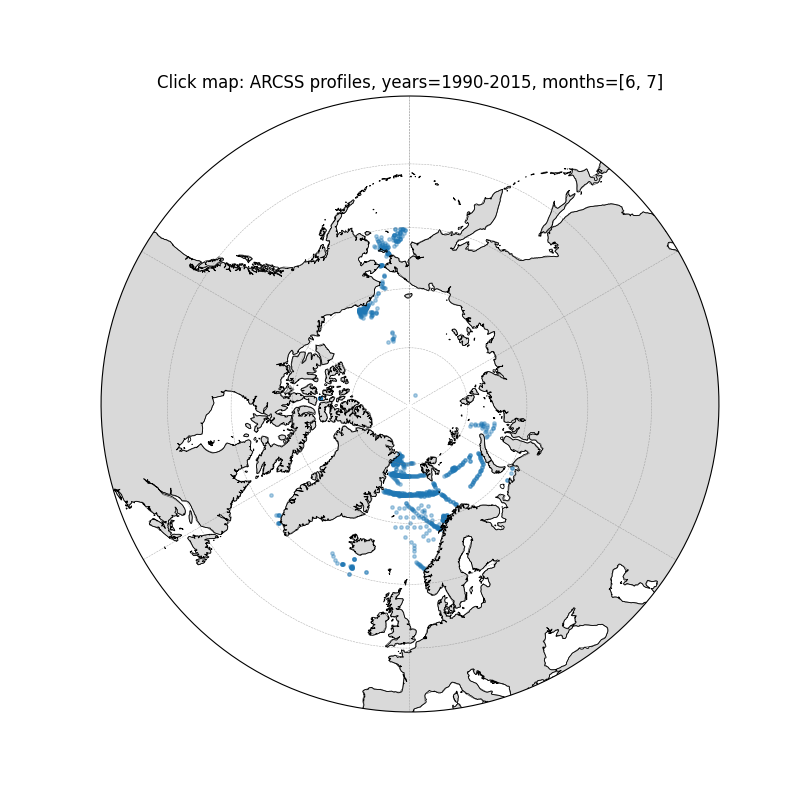

In [ ]:
if profiles_for_map.empty:
    raise ValueError(
        f"No ARCSS profiles found for years {YEAR_MIN}-{YEAR_MAX}, months={MONTHS}"
    )

backend = matplotlib.get_backend().lower().strip()
if "inline" in backend:
    raise RuntimeError(
        "This click selector will not work with inline matplotlib. Run %matplotlib widget or %matplotlib qt."
    )

clicked_artists = []
fig = plt.figure(figsize=(8, 8))
proj = ccrs.NorthPolarStereo()
plate = ccrs.PlateCarree()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, LAT_MIN_MAP, LAT_MAX], crs=plate)

theta = np.linspace(0, 2 * np.pi, 200)
center = np.array([0.5, 0.5])
radius = 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T * radius + center
circle = mpath.Path(verts)
ax.set_boundary(circle, transform=ax.transAxes)

ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.LAND, facecolor="0.85", edgecolor="0.3", linewidth=0.4)
ax.coastlines(resolution="50m", linewidth=0.6)
ax.gridlines(crs=plate, draw_labels=False, linewidth=0.4, color="0.5", alpha=0.6, linestyle="--")

ax.scatter(
    profiles_for_map["lon"],
    profiles_for_map["lat"],
    s=6,
    alpha=0.35,
    transform=plate,
)
ax.set_title(
    f"Click map: ARCSS profiles, years={YEAR_MIN}-{YEAR_MAX}, months={MONTHS}"
)

lons = profiles_for_map["lon"].to_numpy(float)
lats = profiles_for_map["lat"].to_numpy(float)
profile_ids = profiles_for_map.index.to_numpy()
xy = proj.transform_points(plate, lons, lats)
xs = xy[:, 0]
ys = xy[:, 1]
finite = np.isfinite(xs) & np.isfinite(ys)
xs = xs[finite]
ys = ys[finite]
profile_ids = profile_ids[finite]


def on_click_nearest_profile(event):
    if event.inaxes is not ax or event.xdata is None or event.ydata is None:
        return
    dist2 = (xs - event.xdata) ** 2 + (ys - event.ydata) ** 2
    idx = int(np.nanargmin(dist2))
    pid = profile_ids[idx]
    if pid in clicked_profiles:
        print(f"IDxyt={pid} is already selected")
        return
    meta = profiles_for_map.loc[pid]
    order = len(clicked_profiles) + 1
    clicked_profiles.append(pid.item() if hasattr(pid, "item") else pid)
    date_str = pd.to_datetime(meta["date"]).strftime("%Y-%m-%d")
    print(
        f"[{order}] IDxyt={pid}, date={date_str}, lon={meta['lon']:.3f}, lat={meta['lat']:.3f}, "
        f"n_depths={meta['n_depths']}, z_max={meta['z_max']:.1f} m"
    )
    marker = ax.scatter(
        [meta["lon"]],
        [meta["lat"]],
        s=120,
        marker="o",
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        transform=plate,
        zorder=10,
    )
    text = ax.text(
        meta["lon"],
        meta["lat"],
        str(order),
        transform=plate,
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
        zorder=11,
    )
    clicked_artists.extend([marker, text])
    fig.canvas.draw_idle()

cid_click = fig.canvas.mpl_connect("button_press_event", on_click_nearest_profile)
print("Click on the map to add ARCSS profiles. Or skip this and set clicked_profiles manually in the first cell.")


In [ ]:
clicked_profiles

[14373, 1455, 13750, 1057]

In [ ]:
if not clicked_profiles:
    raise ValueError("clicked_profiles is empty. Select profiles on the map or fill the list manually.")

profile_ids = list(dict.fromkeys(clicked_profiles))
missing_ids = [pid for pid in profile_ids if pid not in valid_profiles.index]
if missing_ids:
    raise ValueError(f"These IDxyt are missing in valid_profiles: {missing_ids}")

selected_info = collect_selected_profiles(profile_ids)
selected_info


,pid,arcss_date,lon,lat,aw_date,aw_i,aw_j,aw_lon,aw_lat,sib_month,sib_i,sib_j,sib_lon,sib_lat
0,14373,1990-07-21,11.533,74.750000,2016-07-21,210,221,11.596299,74.860523,2010-07-01,210,221,11.596299,74.860523
1,1455,1993-07-06,-10.046,80.367333,2016-07-06,174,244,-10.170667,80.342519,2010-07-01,174,244,-10.170667,80.342519
2,13750,2003-07-30,-160.669,72.982500,2016-07-28,111,382,-160.483144,72.895837,2010-07-01,111,382,-160.483144,72.895837
3,1057,2001-07-25,154.290,87.900000,2016-07-25,171,309,154.377734,88.165116,2010-07-01,171,309,154.377734,88.165116


In [ ]:
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#393b79", "#637939",
]


def base_figure(title):
    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "geo"}, {"type": "xy"}]],
        column_widths=[0.52, 0.48],
        horizontal_spacing=0.06,
        subplot_titles=["Locations", f"Vertical profiles, 0-{Z_PLOT_MAX} m"],
    )
    fig.update_geos(
        projection_type="orthographic",
        projection_rotation=dict(lat=90, lon=0),
        projection_scale=PROJECTION_SCALE,
        lataxis=dict(range=[LAT_MIN_MAP, LAT_MAX], showgrid=True, gridcolor="rgba(120,120,120,0.35)", gridwidth=0.6),
        lonaxis=dict(range=[-180, 180], showgrid=True, gridcolor="rgba(120,120,120,0.35)", gridwidth=0.6),
        showland=True,
        landcolor="rgb(225,225,225)",
        showocean=True,
        oceancolor="white",
        showcountries=False,
        coastlinecolor="rgb(80,80,80)",
        coastlinewidth=0.6,
        showlakes=False,
        showrivers=False,
        bgcolor="white",
    )
    fig.update_yaxes(title_text="Depth, m", autorange="reversed", range=[Z_PLOT_MAX, 0], row=1, col=2)
    fig.update_layout(
        width=1350,
        height=760,
        title=title,
        template="plotly_white",
        legend=dict(title="Click legend items to hide/show", itemsizing="constant"),
        margin=dict(l=20, r=20, t=80, b=20),
    )
    return fig


profiles_bg = valid_profiles[valid_profiles["lat"].between(LAT_MIN_DATA, LAT_MAX)].copy()

# --- Figure 1: ARCSS ---
fig_arcss = base_figure("ARCSS Chl-a profiles")
fig_arcss.add_trace(
    go.Scattergeo(
        lon=profiles_bg["lon"],
        lat=profiles_bg["lat"],
        mode="markers",
        marker=dict(size=3, color="rgba(70,70,70,0.18)"),
        showlegend=False,
        hoverinfo="skip",
        name="Background ARCSS profiles",
    ),
    row=1,
    col=1,
)
for k, pid in enumerate(profile_ids):
    meta = valid_profiles.loc[pid]
    obs_prof = build_ardyna_profile(pid)
    color = colors[k % len(colors)]
    date_label = pd.Timestamp(meta["date"]).strftime("%Y-%m-%d")
    label = f"IDxyt={pid} | {date_label}"
    fig_arcss.add_trace(
        go.Scattergeo(
            lon=[meta["lon"]],
            lat=[meta["lat"]],
            mode="markers+text",
            marker=dict(size=10, color=color, line=dict(width=1.0, color="black")),
            text=[str(pid)],
            textposition="top center",
            name=label,
            showlegend=False,
            hovertemplate=(
                f"ARCSS IDxyt={pid}<br>date={date_label}<br>"
                "lat=%{lat:.2f}<br>lon=%{lon:.2f}<extra></extra>"
            ),
        ),
        row=1,
        col=1,
    )
    fig_arcss.add_trace(
        go.Scatter(
            x=obs_prof["Chla(mg/m^3)"],
            y=obs_prof["SampleDepth(m)"],
            mode="lines+markers",
            marker=dict(size=5, color=color),
            line=dict(width=1.8, color=color),
            name=label,
            hovertemplate=(
                f"ARCSS IDxyt={pid}<br>date={date_label}<br>"
                "Chl-a=%{x:.3f} mg m^-3<br>Depth=%{y:.1f} m<extra></extra>"
            ),
        ),
        row=1,
        col=2,
    )
fig_arcss.update_xaxes(title_text="Chl-a, mg m^-3", row=1, col=2)
fig_arcss.show()

# --- Figure 2: AW/chl ---
fig_aw = base_figure("AW/chl profiles at nearest available AW dates")
fig_aw.add_trace(
    go.Scattergeo(
        lon=profiles_bg["lon"],
        lat=profiles_bg["lat"],
        mode="markers",
        marker=dict(size=3, color="rgba(70,70,70,0.18)"),
        showlegend=False,
        hoverinfo="skip",
        name="Background ARCSS profiles",
    ),
    row=1,
    col=1,
)
for k, pid in enumerate(profile_ids):
    row = selected_info[selected_info["pid"] == pid].iloc[0]
    color = colors[k % len(colors)]
    field = load_aw_field(row["aw_date"])
    model_info = build_field_profile(field, row["lon"], row["lat"])
    label = f"IDxyt={pid} | AW date={pd.Timestamp(row['aw_date']).strftime('%Y-%m-%d')}"
    fig_aw.add_trace(
        go.Scattergeo(
            lon=[row["lon"], row["aw_lon"]],
            lat=[row["lat"], row["aw_lat"]],
            mode="lines",
            line=dict(width=1.0, color=color, dash="dot"),
            showlegend=False,
            hoverinfo="skip",
            name=label,
        ),
        row=1,
        col=1,
    )
    fig_aw.add_trace(
        go.Scattergeo(
            lon=[row["aw_lon"]],
            lat=[row["aw_lat"]],
            mode="markers+text",
            marker=dict(size=10, color=color, symbol="x"),
            text=[str(pid)],
            textposition="top center",
            name=label,
            showlegend=False,
            hovertemplate=(
                f"AW/chl for IDxyt={pid}<br>model_date={pd.Timestamp(row['aw_date']).strftime('%Y-%m-%d')}<br>"
                f"i={int(row['aw_i'])}, j={int(row['aw_j'])}<br>"
                "lat=%{lat:.2f}<br>lon=%{lon:.2f}<extra></extra>"
            ),
        ),
        row=1,
        col=1,
    )
    fig_aw.add_trace(
        go.Scatter(
            x=model_info["profile"]["value"],
            y=model_info["profile"]["depth_m"],
            mode="lines+markers",
            marker=dict(size=5, color=color, symbol="x"),
            line=dict(width=1.8, color=color),
            name=label,
            hovertemplate=(
                f"AW/chl IDxyt={pid}<br>model_date={pd.Timestamp(row['aw_date']).strftime('%Y-%m-%d')}<br>"
                f"i={int(row['aw_i'])}, j={int(row['aw_j'])}<br>"
                "chl=%{x:.3f} mg m^-3<br>Depth=%{y:.1f} m<extra></extra>"
            ),
        ),
        row=1,
        col=2,
    )
fig_aw.update_xaxes(title_text="AW/chl, mg m^-3", row=1, col=2)
fig_aw.show()

# --- Figure 3: SibCIOM ---
fig_sib = base_figure("SibCIOM phyto profiles at nearest available months")
fig_sib.add_trace(
    go.Scattergeo(
        lon=profiles_bg["lon"],
        lat=profiles_bg["lat"],
        mode="markers",
        marker=dict(size=3, color="rgba(70,70,70,0.18)"),
        showlegend=False,
        hoverinfo="skip",
        name="Background ARCSS profiles",
    ),
    row=1,
    col=1,
)
for k, pid in enumerate(profile_ids):
    row = selected_info[selected_info["pid"] == pid].iloc[0]
    color = colors[k % len(colors)]
    field = load_sib_field(row["sib_month"])
    model_info = build_field_profile(field, row["lon"], row["lat"])
    label = f"IDxyt={pid} | SibCIOM month={pd.Timestamp(row['sib_month']).strftime('%Y-%m')}"
    fig_sib.add_trace(
        go.Scattergeo(
            lon=[row["lon"], row["sib_lon"]],
            lat=[row["lat"], row["sib_lat"]],
            mode="lines",
            line=dict(width=1.0, color=color, dash="dot"),
            showlegend=False,
            hoverinfo="skip",
            name=label,
        ),
        row=1,
        col=1,
    )
    fig_sib.add_trace(
        go.Scattergeo(
            lon=[row["sib_lon"]],
            lat=[row["sib_lat"]],
            mode="markers+text",
            marker=dict(size=10, color=color, symbol="x"),
            text=[str(pid)],
            textposition="top center",
            name=label,
            showlegend=False,
            hovertemplate=(
                f"SibCIOM for IDxyt={pid}<br>model_month={pd.Timestamp(row['sib_month']).strftime('%Y-%m')}<br>"
                f"i={int(row['sib_i'])}, j={int(row['sib_j'])}<br>"
                "lat=%{lat:.2f}<br>lon=%{lon:.2f}<extra></extra>"
            ),
        ),
        row=1,
        col=1,
    )
    fig_sib.add_trace(
        go.Scatter(
            x=model_info["profile"]["value"],
            y=model_info["profile"]["depth_m"],
            mode="lines+markers",
            marker=dict(size=5, color=color, symbol="x"),
            line=dict(width=1.8, color=color),
            name=label,
            hovertemplate=(
                f"SibCIOM IDxyt={pid}<br>model_month={pd.Timestamp(row['sib_month']).strftime('%Y-%m')}<br>"
                f"i={int(row['sib_i'])}, j={int(row['sib_j'])}<br>"
                "phyto=%{x:.3f}<br>Depth=%{y:.1f} m<extra></extra>"
            ),
        ),
        row=1,
        col=2,
    )
fig_sib.update_xaxes(title_text="SibCIOM phyto, model units", row=1, col=2)
fig_sib.show()
